Successfully loaded and prepared naruto.webp.


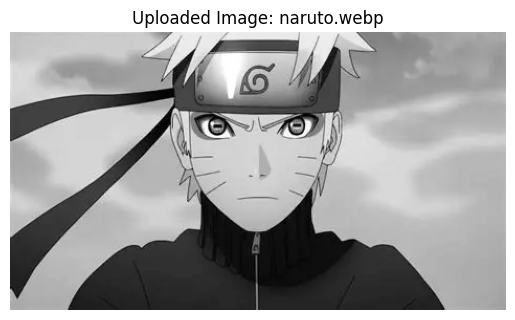

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# IMPORTANT: Replace 'naruto.jpg' with the actual filename of your uploaded image
image_path = 'naruto.webp'

# Load the image
try:
    custom_img = cv2.imread(image_path)
    if custom_img is None:
        raise FileNotFoundError(f"Image not found at {image_path}. Please check the filename and path.")

    # Convert to grayscale if it's a color image
    if len(custom_img.shape) == 3:
        custom_img_gray = cv2.cvtColor(custom_img, cv2.COLOR_BGR2GRAY)
    else:
        custom_img_gray = custom_img

    # Normalize pixel values to 0-1 range (similar to Fashion-MNIST)
    custom_img_normalized = custom_img_gray / 255.0

    print(f"Successfully loaded and prepared {image_path}.")

    plt.imshow(custom_img_normalized, cmap='gray')
    plt.title(f"Uploaded Image: {image_path}")
    plt.axis('off')
    plt.show()

except FileNotFoundError as e:
    print(e)
    print("Please upload your image to the Colab environment using the 'Files' tab on the left sidebar.")
except Exception as e:
    print(f"An error occurred: {e}")


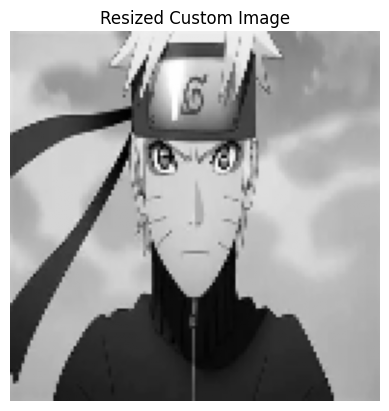

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Use the custom image (custom_img_normalized) loaded previously
# custom_img_normalized is already a 2D array and normalized.
img = custom_img_normalized

# Resize for clarity (if not already 128x128, though custom_img_normalized from PpQOWAEFukBq is already in a good state for this)
resized = cv2.resize(img,(128,128))

plt.imshow(resized,cmap='gray')
plt.title("Resized Custom Image")
plt.axis('off')
plt.show()

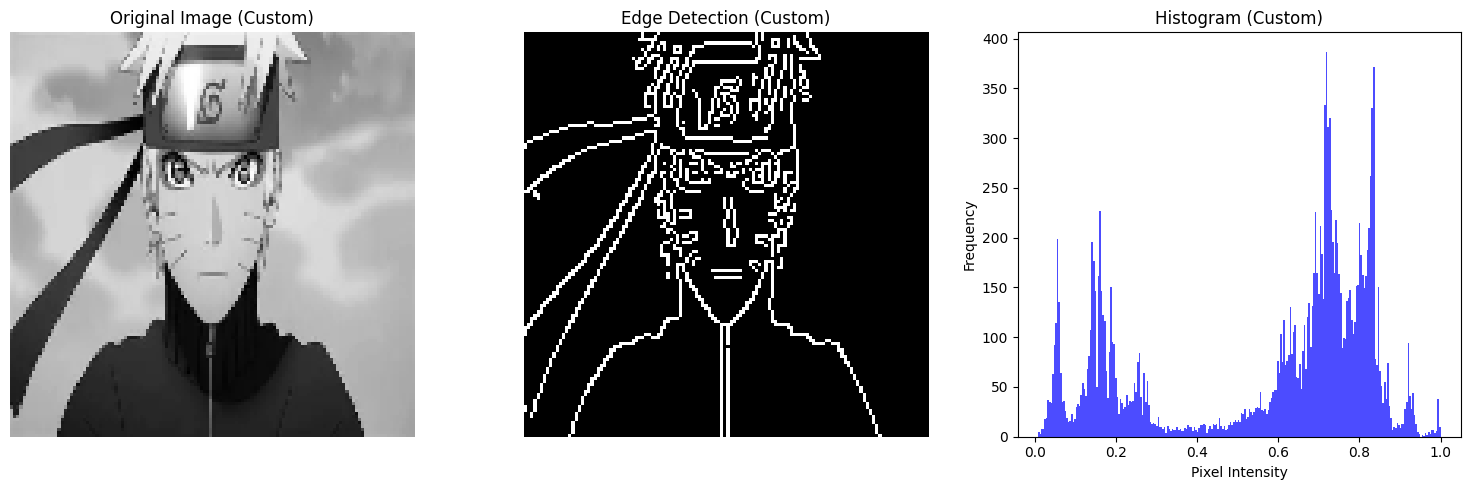

In [ ]:
 import cv2
import matplotlib.pyplot as plt
import numpy as np

# Assuming custom_img_normalized is already loaded and available from a previous cell (PpQOWAEFukBq)

# Resize the custom image for clarity and consistent processing with the original notebook flow
# Ensure custom_img_normalized is accessible here and is a 2D array of floats from 0-1
resized = cv2.resize(custom_img_normalized,(128,128))

# Assuming 'resized' is your preprocessed grayscale image (values between 0 and 1)
# Convert to uint8 for edge detection
edges = cv2.Canny((resized * 255).astype('uint8'), 100, 200)

plt.figure(figsize=(15,5))

# Original Image
plt.subplot(1,3,1)
plt.imshow(resized, cmap='gray')
plt.title("Original Image (Custom)")
plt.axis('off')

# Edge Detection
plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Custom)")
plt.axis('off')

# Histogram
plt.subplot(1,3,3)
plt.hist(resized.ravel(), bins=256, color='blue', alpha=0.7)
plt.title("Histogram (Custom)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### Visualizing Key Image Variables from Kernel State

Here are graphical representations of some of the image variables currently in your kernel:

*   **Grayscale Image (`custom_img_gray`)**: The initial conversion of your color image to grayscale.
*   **Normalized Grayscale Image (`custom_img_normalized`)**: The grayscale image with pixel values scaled between 0 and 1.
*   **Edge Detection (`edges`)**: The output of the Canny edge detection algorithm applied to the normalized image.

In [ ]:
import os
print("Files in current directory:")
print(os.listdir('.'))


Files in current directory:
['.config', 'sample_data']


After running the above cell, you should see your image file listed. If the name is different from `naruto.jpg`, please update the `image_path` variable in the cell above (cell `PpQOWAEFukBq`) with the correct filename, and then re-run that cell.

For example, if you uploaded `my_naruto_picture.png`, you would change:

```python
image_path = 'naruto.jpg'
```
to
```python
image_path = 'my_naruto_picture.png'
```

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Flatten images for SVM
X = x_train.reshape(len(x_train),-1)[:5000]   # subset for speed
y = y_train[:5000]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

svm_model = SVC(kernel='rbf',C=5,gamma='scale')
svm_model.fit(X_train,y_train)

print("SVM Accuracy:",svm_model.score(X_test,y_test))


SVM Accuracy: 0.865


### Visualizing SVM Predictions on Fashion-MNIST Test Set

To understand the SVM's performance visually, let's look at some examples from the test set. We'll display images that were correctly classified and images that were misclassified, along with their true and predicted labels.

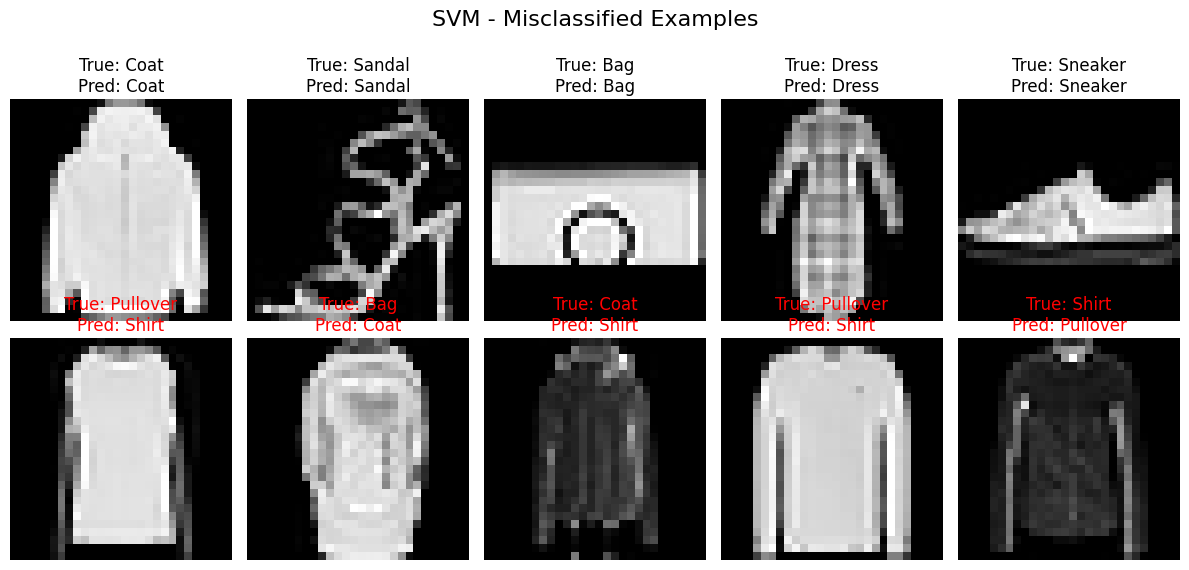

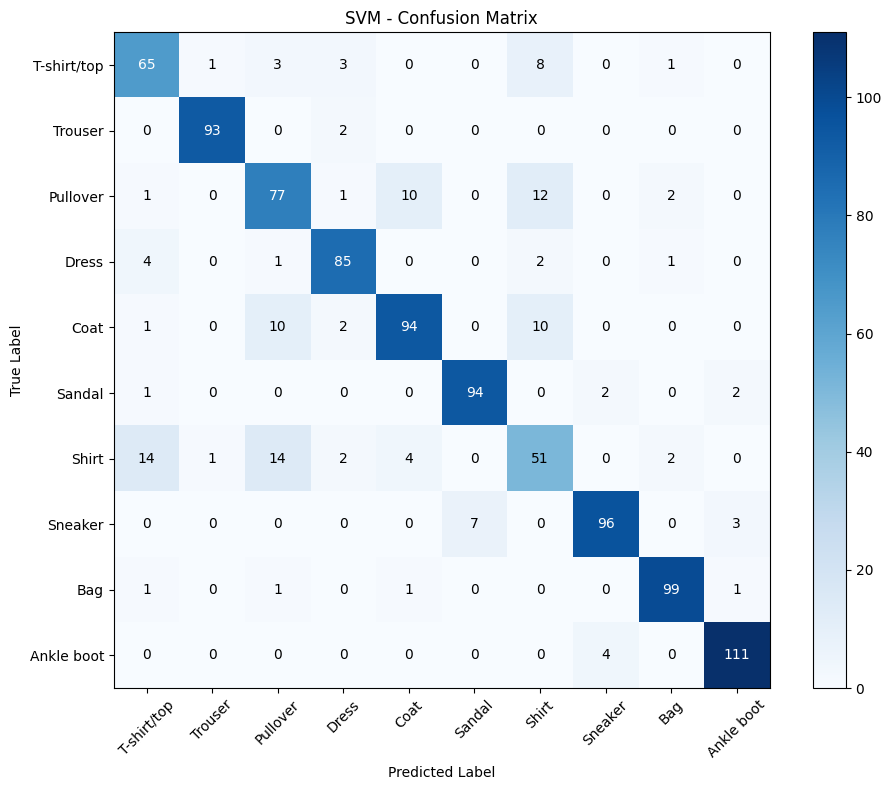

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import tensorflow as tf # Required for loading Fashion-MNIST

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values (0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images for SVM
X = x_train.reshape(len(x_train),-1)[:5000]   # subset for speed
y = y_train[:5000]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

svm_model = SVC(kernel='rbf',C=5,gamma='scale')
svm_model.fit(X_train,y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Get misclassified indices
misclassified_indices = np.where(y_pred != y_test)[0]
correctly_classified_indices = np.where(y_pred == y_test)[0]

# Define class names for Fashion-MNIST
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# --- Visualize some correctly classified examples ---
plt.figure(figsize=(12, 6))
plt.suptitle('SVM - Correctly Classified Examples', fontsize=16)
for i, idx in enumerate(np.random.choice(correctly_classified_indices, size=5, replace=False)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')

# --- Visualize some misclassified examples ---
plt.suptitle('SVM - Misclassified Examples', fontsize=16)
for i, idx in enumerate(np.random.choice(misclassified_indices, size=5, replace=False)):
    plt.subplot(2, 5, i + 6) # Continue on the second row
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", color='red')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

# Optionally, display a confusion matrix for a more quantitative visual summary
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('SVM - Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add text annotations
fmt = 'd'
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7500 - loss: 0.6873
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7500 - loss: 0.6596
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2500 - loss: 0.7219
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2500 - loss: 0.6958
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7500 - loss: 0.6657
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7500 - loss: 0.6540
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7500 - loss: 0.6451
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.6048
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.6253
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7500 - loss: 0.6669


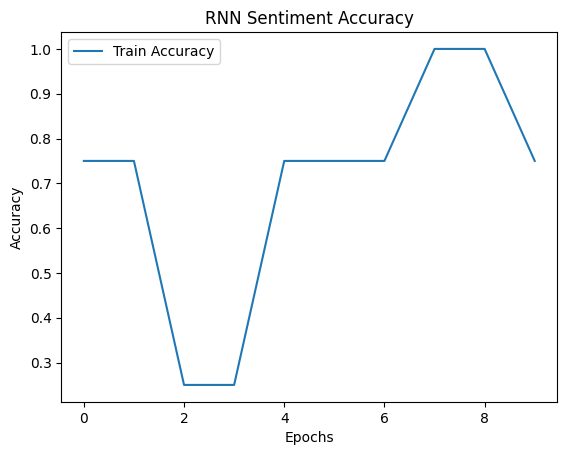

In [ ]:
# =========================
# Program 5: RNN Sentiment Analysis
# =========================

import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

# Example dataset (text + labels)
texts = ["Fashion is art", "I dislike cheap shoes", "Sneakers are cool", "This shirt is ugly"]
labels = [1, 0, 1, 0]   # 1 = Positive, 0 = Negative

# Tokenize text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
seq = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(seq)

# Build RNN model
rnn_model = Sequential([
    Embedding(100, 16),
    SimpleRNN(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = rnn_model.fit(padded, np.array(labels), epochs=10, verbose=1)

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.title("RNN Sentiment Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### Visualizing CNN Training Performance

Let's build a simple Convolutional Neural Network (CNN) to classify Fashion-MNIST images and visualize its training accuracy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Load Fashion-MNIST dataset (if not already loaded)
(x_train_cnn, y_train_cnn), (x_test_cnn, y_test_cnn) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to 0-1 range
x_train_cnn = x_train_cnn / 255.0
x_test_cnn = x_test_cnn / 255.0

# Reshape data to include a channel dimension (for CNN input: height, width, channels)
x_train_cnn = x_train_cnn.reshape((x_train_cnn.shape[0], 28, 28, 1))
x_test_cnn = x_test_cnn.reshape((x_test_cnn.shape[0], 28, 28, 1))

print("Fashion-MNIST data loaded and preprocessed for CNN.")
print(f"x_train_cnn shape: {x_train_cnn.shape}")
print(f"x_test_cnn shape: {x_test_cnn.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Fashion-MNIST data loaded and preprocessed for CNN.
x_train_cnn shape: (60000, 28, 28, 1)
x_test_cnn shape: (10000, 28, 28, 1)


In [2]:
# Define the CNN model architecture
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax') # 10 classes for Fashion-MNIST
])

# Compile the model
cnn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7141 - loss: 0.7900 - val_accuracy: 0.7950 - val_loss: 0.5538
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8331 - loss: 0.4672 - val_accuracy: 0.8430 - val_loss: 0.4438
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8568 - loss: 0.3992 - val_accuracy: 0.8310 - val_loss: 0.4498
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8673 - loss: 0.3637 - val_accuracy: 0.8475 - val_loss: 0.4177
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8835 - loss: 0.3231 - val_accuracy: 0.8590 - val_loss: 0.3774


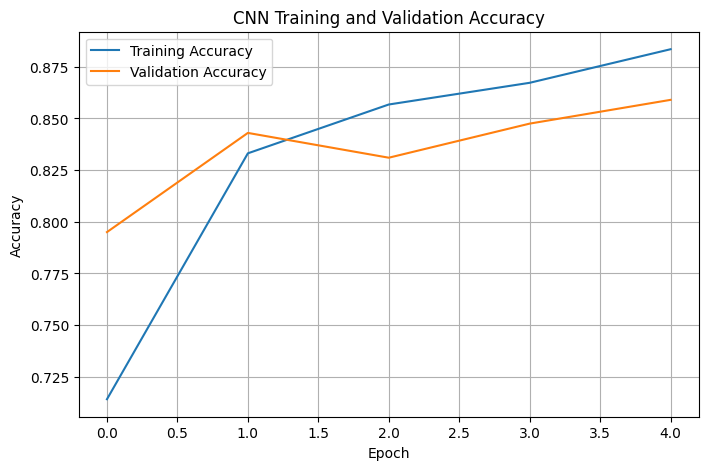

In [3]:
# Train the CNN model
# Using a small subset and fewer epochs for demonstration purposes to keep execution quick
history_cnn = cnn_model.fit(
    x_train_cnn[:10000], y_train_cnn[:10000], # Train on first 10,000 samples
    epochs=5, # Using 5 epochs for a quick demo
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1
)

# Plot training accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


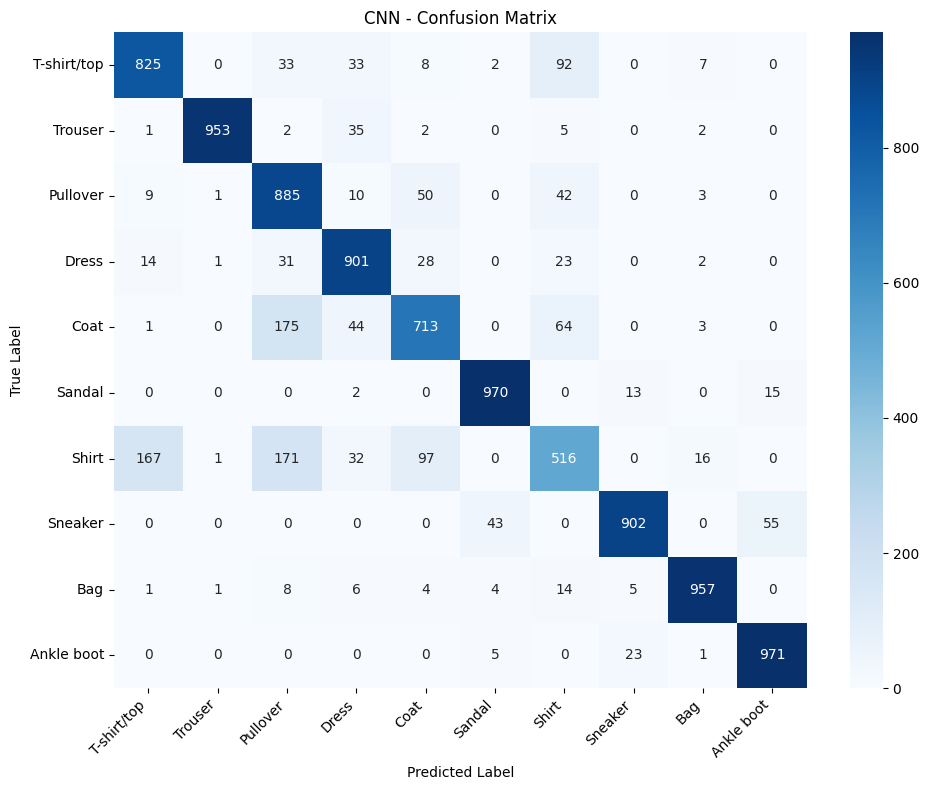

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict the classes for the test data
y_pred_cnn_probs = cnn_model.predict(x_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

# Get the true labels for the test data
y_true_cnn = y_test_cnn

# Compute the confusion matrix
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

# Define class names for Fashion-MNIST for better visualization
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('CNN - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Feature Detection: Visualizing ORB Keypoints

Feature detection is a crucial step in many computer vision applications, allowing us to identify distinctive points in an image. Here, we'll use the ORB (Oriented FAST and Rotated BRIEF) algorithm to find keypoints in our custom image and visualize them.

Image 'naruto.webp' reloaded and resized for ORB detection.


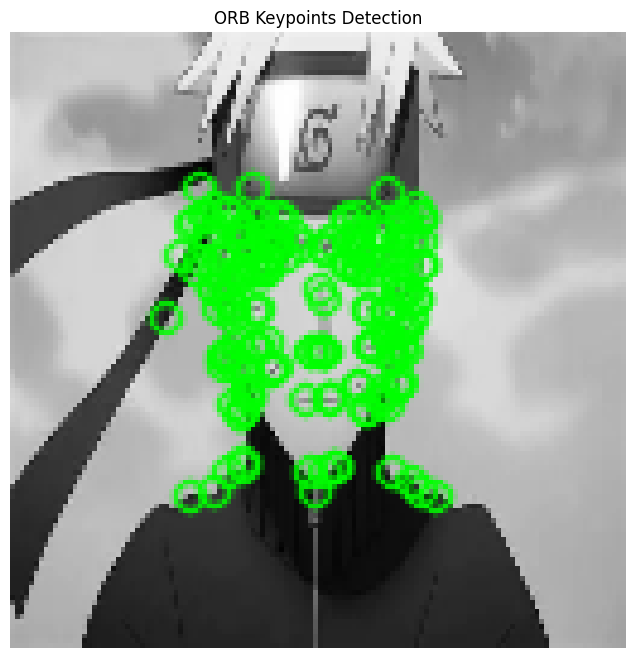

Number of keypoints detected: 178


In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Ensure `resized` image (128x128, normalized grayscale) is available.
# Re-loading and resizing here for robustness against kernel resets or skipped cell execution.

# Assuming 'image_path' is defined globally (e.g., from cell PpQOWAEFukBq)
# If image_path is not defined, you might need to manually set it here:
image_path = 'naruto.webp' # Fallback, adjust if your image filename is different

try:
    custom_img = cv2.imread(image_path)
    if custom_img is None:
        raise FileNotFoundError(f"Image not found at {image_path}. Please check the filename and path.")

    # Convert to grayscale
    custom_img_gray = cv2.cvtColor(custom_img, cv2.COLOR_BGR2GRAY) if len(custom_img.shape) == 3 else custom_img

    # Normalize and resize
    custom_img_normalized = custom_img_gray / 255.0
    resized = cv2.resize(custom_img_normalized, (128, 128))
    print(f"Image '{image_path}' reloaded and resized for ORB detection.")

except FileNotFoundError as e:
    print(e)
    print("Please ensure 'naruto.webp' is uploaded to the Colab environment or update 'image_path'.")
    # Exit gracefully if image can't be loaded
    resized = None # Set resized to None to prevent further errors if image loading fails
except Exception as e:
    print(f"An error occurred during image loading/resizing: {e}")
    resized = None

if resized is not None:
    # Initialize ORB detector
    orb = cv2.ORB_create()

    # Convert the normalized float image back to uint8 for ORB (values 0-255)
    img_for_orb = (resized * 255).astype(np.uint8)

    # Find the keypoints and descriptors with ORB
    keypoints, descriptors = orb.detectAndCompute(img_for_orb, None)

    # Draw only the keypoints on the original image
    img_keypoints = cv2.drawKeypoints(img_for_orb, keypoints, None, color=(0, 255, 0), flags=0)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_keypoints, cmap='gray')
    plt.title('ORB Keypoints Detection')
    plt.axis('off')
    plt.show()

    print(f"Number of keypoints detected: {len(keypoints)}")
else:
    print("Skipping ORB detection because the image could not be loaded or resized.")